#### Fixed Points + Hamming Analysis

In [ ]:
#import matplotlib.pyplot as plt
#import networkx as nx
#import matplotlib as mpl
#import pandas as pd
#import numpy as np
#import re
#import random as rn
#import warnings
#from tqdm import tqdm
#import os
#import glob
#from sklearn.cluster import DBSCAN, AgglomerativeClustering
#import networkx as nx
#import umap
#from sklearn.decomposition import PCA
#from sklearn.manifold import TSNE
#from scipy.cluster.hierarchy import dendrogram
#from joblib import Parallel, delayed
#from pathlib import Path
#from matplotlib.transforms import blended_transform_factory
#import pandas as pd
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import mean_squared_error, r2_score
#from sklearn.pipeline import make_pipeline
#from sklearn.preprocessing import PolynomialFeatures
#from sklearn.linear_model import Ridge
#from matplotlib.colors import TwoSlopeNorm
#from scipy import stats
#import tqdm
#from itertools import combinations
#
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#
#warnings.filterwarnings("ignore")
#
#def Hamming_Distance(state1, state2):
#    if len(state1) != len(state2):
#        raise ValueError("The two states have different sizes\n")
#    ovlp = 0
#    for i in range(len(state1)):
#        ovlp = ovlp + state1.iloc[i] * state2.iloc[i]
#    ovlp = ovlp * (1/len(state1))
#    return (1 - ovlp)/2
#
#
#
#def weights_cluster(data, W, m = None, s = 0.5):
#    if isinstance(W, float):
#        W = [W]
#
#    compressor = umap.UMAP()
#    to_umap_instances = []
#    colors = []
#    for W_val in tqdm(W):
#        for rep in data["Rep"].unique():
#
#            fname = f"Weights_rep={rep}_W={W_val:.3f}_k=1.000_eta_w=1.000_eta_s=1.000.csv"
#            w = pd.read_csv(fname, header=None).to_numpy()
#            w = w[np.triu_indices(w.shape[0], k=1)]
#            to_umap_instances.append(w)
#
#            if (m != None):
#                colors.append(data.iloc[(data["W"] == W_val) & (data["Rep"] == rep),2].to_numpy() > m)
#            else:
#                colors.append(W_val * 20)
#
#    embedding = compressor.fit_transform(to_umap_instances)
#
#    plt.scatter(embedding[:, 0],embedding[:, 1], c = colors, s = s)
#    plt.title('UMAP projection of the Weights Space')
#
#
#
#
#def weight_print(data, fn):
#    rep = fn.split("_")[1].split("=")[1]
#    W = fn.split("_")[2].split("=")[1]
#
#    weights  = pd.read_csv(fn, header=None)
#    M = np.abs(weights.to_numpy()).max()
#    norm = TwoSlopeNorm(vmin=-M, vcenter=0, vmax=M)
#
#    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
#
#    im0 = ax[0].imshow(weights, cmap="coolwarm", norm=norm)
#    fig.colorbar(im0, ax=ax[0])
#    ax[0].set_title("Weights")
#
#    im1 = ax[1].imshow(np.array(weights >= 0, int) - np.array(weights <= 0, int), cmap="gray")
#    fig.colorbar(im1, ax=ax[1])
#    ax[1].set_title("Weights Sign")
#
#    plt.tight_layout()
#    plt.show()
#    print(f"Fixed Points: {data.loc[(data['Rep'] == float(rep)) & (data['W'] == float(W)), 'Fixed Points'].iloc[0]}")
#    print(f"Portion of positive synapses: {np.sum(weights > 0)/(weights.shape[0]**2)}")
#    print("Min:", weights.to_numpy().min())
#    print("Max:", weights.to_numpy().max())
#    print("Max - Min:", weights.to_numpy().max() - weights.to_numpy().min())
#    print("Mean:", weights.to_numpy().mean())
#    print("Std:", weights.to_numpy().std())
#    print("Mean absolute difference from mean:", np.abs(weights.to_numpy() - weights.to_numpy().mean()).mean())

ModuleNotFoundError: No module named 'matplotlib'

In [5]:
import re
import random as rn
import warnings
from tqdm import tqdm
import os
import glob
from sklearn.cluster import DBSCAN, AgglomerativeClustering
import networkx as nx
#import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram
from joblib import Parallel, delayed
from pathlib import Path
from matplotlib.transforms import blended_transform_factory
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
import tqdm
from itertools import combinations


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
data = pd.read_csv("Data.csv")
data["cycle_fraction"] = data["cycles_runs"] / 100
print(data)

         N    W    k  ETA_w  ETA_s  fp_runs  cycles_runs  max_steps_runs  \
0     1000  0.0  100    0.0   0.00        0            0             100   
1     1000  0.0  100    0.0   0.05        0            0             100   
2     1000  0.0  100    0.0   0.10        0            0             100   
3     1000  0.0  100    0.0   0.15        0            0             100   
4     1000  0.0  100    0.0   0.20        0            0             100   
...    ...  ...  ...    ...    ...      ...          ...             ...   
4846  1000  0.5  100    1.0   0.80        0          100               0   
4847  1000  0.5  100    1.0   0.85        0          100               0   
4848  1000  0.5  100    1.0   0.90        0          100               0   
4849  1000  0.5  100    1.0   0.95        0          100               0   
4850  1000  0.5  100    1.0   1.00        0          100               0   

      fixed_points  updates  hamming  cycle_fraction  
0                0        0     

In [53]:
data.iloc[:, 5].sum()

np.int64(0)

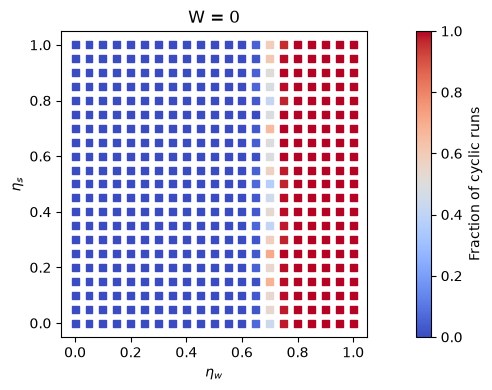

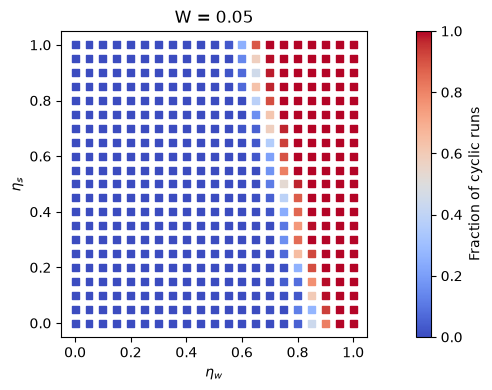

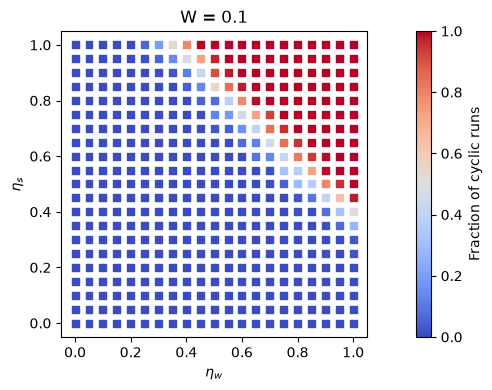

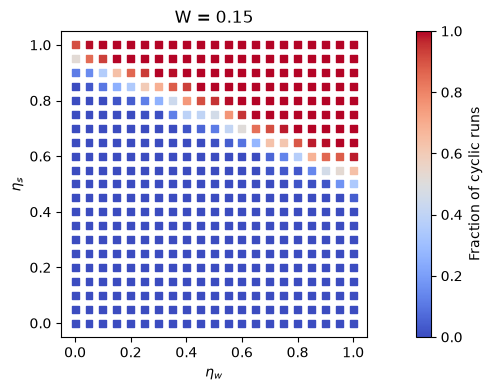

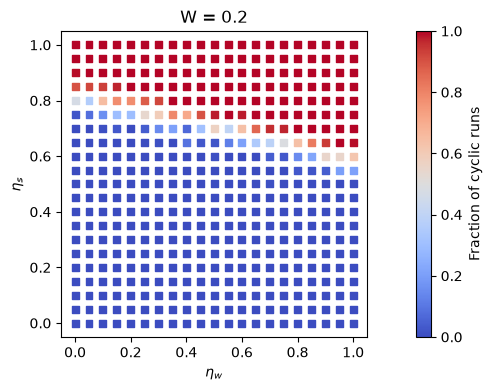

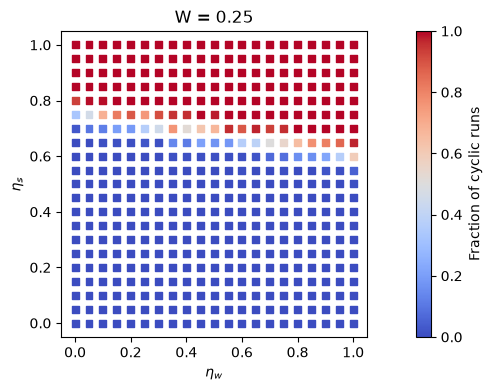

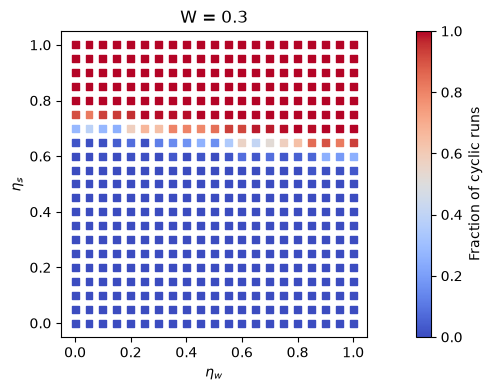

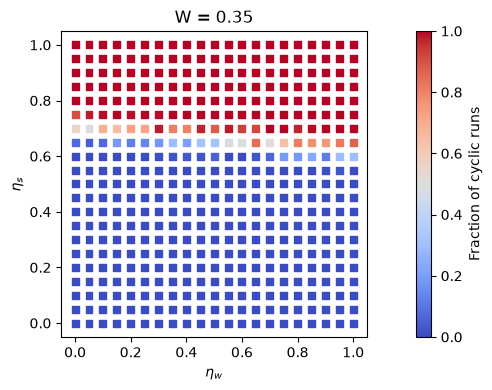

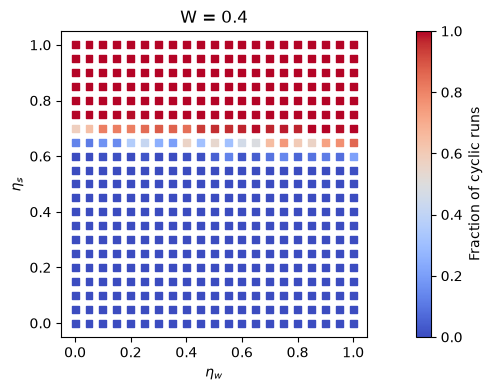

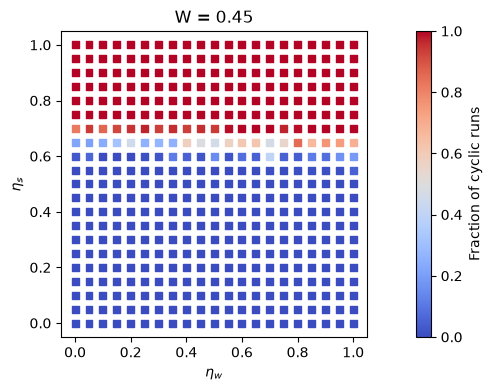

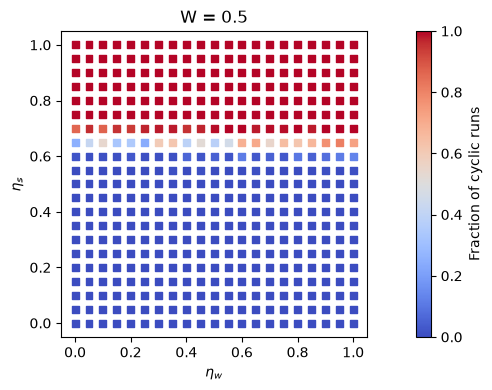

In [54]:
w_values = np.sort(data["W"].unique())

for W in w_values:
    d = data[data["W"] == W]

    fig, ax = plt.subplots(figsize=(10, 4))

    sc = ax.scatter(
        d["ETA_w"],
        d["ETA_s"],
        c=d["cycle_fraction"],
        marker="s",
        s=25,
        cmap="coolwarm"
    )

    ax.set_title(f"W = {W:g}")
    ax.set_xlabel(r"$\eta_w$")
    ax.set_ylabel(r"$\eta_s$")
    ax.set_xticks(np.arange(0, 1.2, 0.2))
    ax.set_yticks(np.arange(0, 1.2, 0.2))
    ax.set_aspect("equal")

    fig.colorbar(
        sc,
        ax=ax,
        label="Fraction of cyclic runs"
    )

    plt.tight_layout()
    plt.show()